# Previsão de Decaimento Orbital

**OrbitHam · Global Solution FIAP**

Satélites em órbita baixa (LEO) perdem altitude continuamente por causa do arrasto atmosférico. Saber *quanto* e *quão rápido* um satélite decai ajuda a planejar operações e estimar a reentrada.

Aqui propagamos o TLE atual de cada satélite no tempo (SGP4, via Skyfield), amostramos a altitude, suavizamos a oscilação por órbita em uma **média diária** e ajustamos uma **regressão** para estimar a taxa de decaimento e um horizonte de reentrada.

> **Limitação (honesta):** um único TLE propagado para muito longe é aproximado. O SGP4 modela o arrasto pelo termo B*, então a *tendência* é significativa, mas datas absolutas de reentrada são estimativas grosseiras.

> ### Resumo para o vídeo
> **O que faz:** prevê o decaimento (perda de altitude) de satélites propagando o TLE com SGP4 e ajustando uma regressão.
>
> **Stack:** Python · Skyfield/SGP4 · Pandas · NumPy · Matplotlib/Seaborn.
>
> **Resultado (ISS):** queda de ~69 km/ano, reentrada estimada por volta de **2027** (~3 anos).
>
> **Achado:** satélites baixos (ISS, ~420 km) decaem rápido; altos (AO-7, ~1450 km) são quase estáveis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
from datetime import datetime, timezone, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import orbitham_analytics as oa

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4.5)

# Data de referência fixa (próxima da época dos TLEs) -> reproduzível.
START = datetime(2024, 10, 25, tzinfo=timezone.utc)

## 1. Carregando os satélites

In [2]:
tles = oa.load_sample()
pd.DataFrame([(t.norad_id, t.name, t.category) for t in tles],
             columns=['norad_id', 'nome', 'categoria'])

,norad_id,nome,categoria
0,25544,ISS (ZARYA),stations
1,43017,FOX-1D (AO-92),amateur
2,7530,AO-7 (OSCAR 7),amateur
3,40967,FOX-1A (AO-85),amateur


## 2. Série temporal de altitude (ISS)

Propagamos 2 anos e amostramos a altitude a cada 6 horas.

In [3]:
iss = next(t for t in tles if t.norad_id == 25544)
serie = oa.altitude_series(iss.tle_1, iss.tle_2, iss.name,
                           days=730, step_hours=6, start=START)
serie.head()

,time,altitude_km
0,2024-10-25 00:00:00+00:00,419.134987
1,2024-10-25 06:00:00+00:00,417.935988
2,2024-10-25 12:00:00+00:00,420.772788
3,2024-10-25 18:00:00+00:00,432.171558
4,2024-10-26 00:00:00+00:00,437.343416


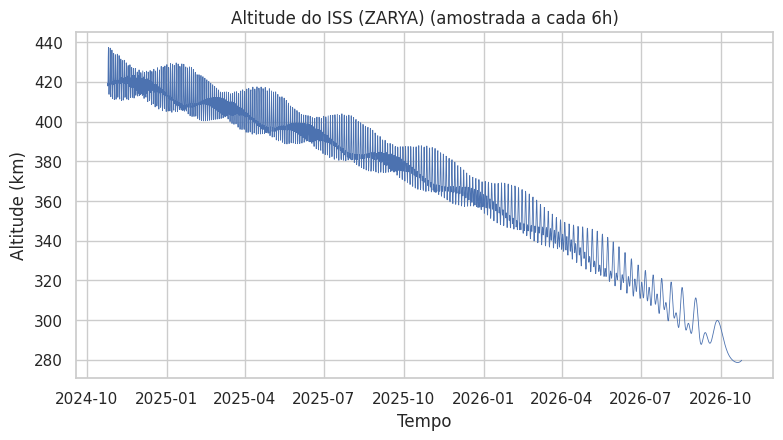

In [4]:
plt.plot(serie['time'], serie['altitude_km'], lw=0.6)
plt.title(f'Altitude do {iss.name} (amostrada a cada 6h)')
plt.xlabel('Tempo'); plt.ylabel('Altitude (km)')
plt.show()

## 3. Média diária e tendência de decaimento

A altitude oscila a cada órbita (órbita elíptica). A média diária revela a tendência de fundo.

Taxa média de decaimento: -68.9 km/ano


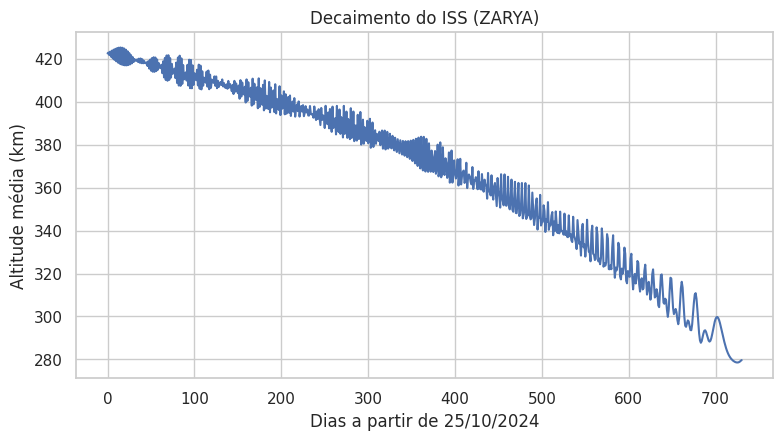

In [5]:
daily = oa.daily_mean_altitude(serie)
rate = oa.decay_rate_km_per_year(daily)
print(f'Taxa média de decaimento: {rate:.1f} km/ano')

plt.plot(daily['day'], daily['altitude_km'])
plt.title(f'Decaimento do {iss.name}')
plt.xlabel('Dias a partir de ' + START.strftime('%d/%m/%Y'))
plt.ylabel('Altitude média (km)')
plt.show()

## 4. Regressão e estimativa de reentrada

Ajustamos um polinômio (grau 2) à altitude média e extrapolamos até o limiar de reentrada (120 km).

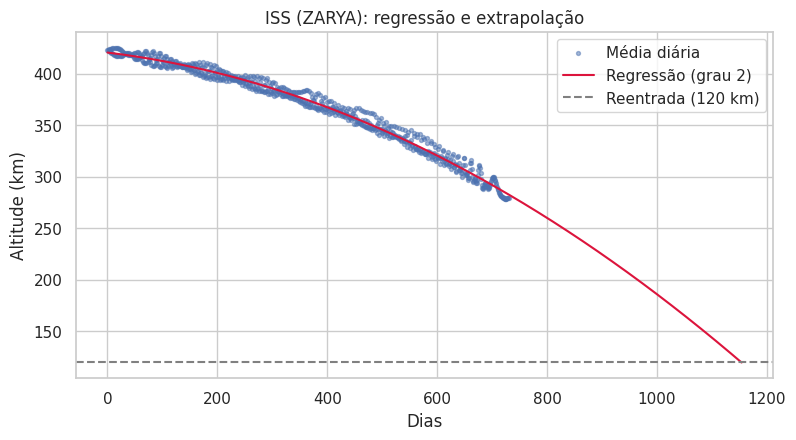

Estimativa ingênua de reentrada: dia 1154 (~3.2 anos), por volta de 12/2027


In [6]:
poly, coeffs = oa.fit_decay(daily, degree=2)
reentry_day = oa.estimate_reentry_day(poly)

x_fit = np.linspace(0, (reentry_day or daily['day'].max()), 300)
plt.scatter(daily['day'], daily['altitude_km'], s=8, alpha=0.5, label='Média diária')
plt.plot(x_fit, poly(x_fit), color='crimson', label='Regressão (grau 2)')
plt.axhline(oa.REENTRY_ALTITUDE_KM, color='gray', ls='--',
            label=f'Reentrada ({oa.REENTRY_ALTITUDE_KM:.0f} km)')
plt.title(f'{iss.name}: regressão e extrapolação')
plt.xlabel('Dias'); plt.ylabel('Altitude (km)'); plt.legend(); plt.show()

if reentry_day:
    data_reentrada = START + timedelta(days=reentry_day)
    print(f'Estimativa ingênua de reentrada: dia {reentry_day} '
          f'(~{reentry_day/365.25:.1f} anos), por volta de '
          f'{data_reentrada.strftime("%m/%Y")}')
else:
    print('Sem reentrada no horizonte avaliado.')

## 5. Comparando o decaimento entre satélites

Nem todos decaem igual: depende da altitude e do arrasto.

In [7]:
linhas = []
for t in tles:
    s = oa.altitude_series(t.tle_1, t.tle_2, t.name, days=730, step_hours=12, start=START)
    d = oa.daily_mean_altitude(s)
    linhas.append({'satelite': t.name,
                   'altitude_media_km': round(d['altitude_km'].mean(), 1),
                   'decaimento_km_ano': round(oa.decay_rate_km_per_year(d), 1)})
resumo = pd.DataFrame(linhas).sort_values('decaimento_km_ano')
resumo

,satelite,altitude_media_km,decaimento_km_ano
0,ISS (ZARYA),366.6,-68.9
1,FOX-1D (AO-92),469.6,-42.8
3,FOX-1A (AO-85),624.4,-12.3
2,AO-7 (OSCAR 7),1460.8,-0.1


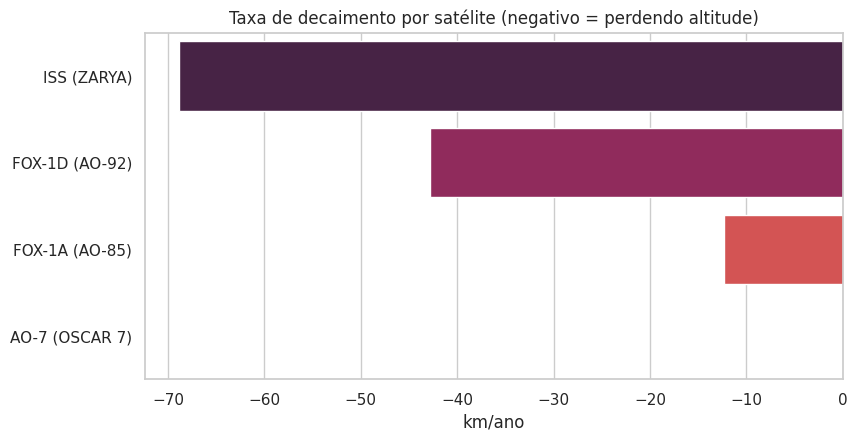

In [8]:
ax = sns.barplot(data=resumo, x='decaimento_km_ano', y='satelite',
                 hue='satelite', palette='rocket', legend=False)
ax.set_title('Taxa de decaimento por satélite (negativo = perdendo altitude)')
ax.set_xlabel('km/ano'); ax.set_ylabel('')
plt.show()

## Conclusões

- Satélites em órbita mais baixa (como a **ISS**, ~420 km) perdem altitude bem mais rápido do que satélites altos (como o **AO-7**, ~1450 km), praticamente estáveis.
- A regressão dá uma estimativa de ordem de grandeza para a reentrada, útil para priorizar quais satélites monitorar.
- **Limitação:** propagar um único TLE por anos é aproximado; para uso real, recalcular com TLEs atualizados periodicamente (o OrbitHam já guarda histórico de TLE, que poderia alimentar esta análise com dados medidos).